In [32]:
import xarray as xr 
from anemoi.datasets import open_dataset
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [33]:
!anemoi-datasets inspect CERRA5.zarr

📦 Path          : CERRA5.zarr
🔢 Format version: 0.30.0

📅 Start      : 2023-01-01 00:00
📅 End        : 2024-10-31 21:00
⏰ Frequency  : 3h
🚫 Missing    : 0
🌎 Resolution : None
🌎 Field shape: [55, 61]

📐 Shape      : 5,360 × 9 × 1 × 3,355 (617.4 MiB)
💽 Size       : 380.7 MiB (380.7 MiB)
📁 Files      : 5,404

   Index │ Variable   │         Min │     Max │     Mean │    Stdev
   ──────┼────────────┼─────────────┼─────────┼──────────┼─────────
       0 │ mcc        │           0 │     100 │  35.1832 │  38.1831
       1 │ msl        │     95813.2 │  104564 │   101450 │  1109.45
       2 │ orog       │    -3.39038 │  616.61 │  117.097 │  134.836
       3 │ si10       │   0.0011828 │ 28.6761 │  4.43411 │   2.7958
       4 │ sr         │ 3.36711e-07 │ 1.32257 │ 0.289842 │ 0.209485
       5 │ t2m        │     261.331 │  309.39 │  283.925 │  6.34137
       6 │ wdir10     │ 2.64237e-06 │ 360.001 │  191.956 │  91.2913
       7 │ wind_power │           0 │     9.5 │  2.10144 │  2.90018
       8 │ w

In [62]:
ds=open_dataset("CERRA5.zarr")

12.04315185546875

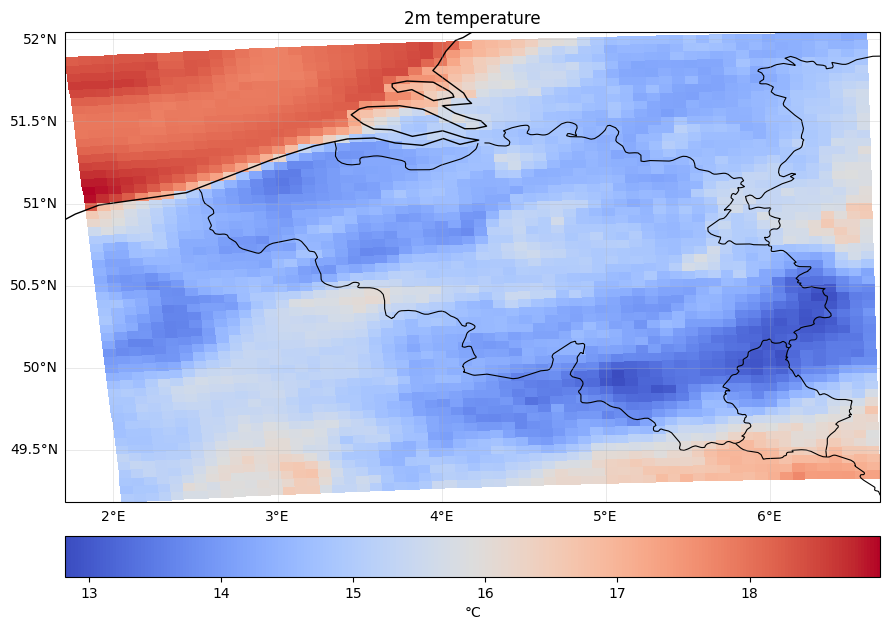

In [63]:
time = 1680
var  = 5          # 5 = t2m in your index listing
ny, nx = 55, 61   # from "Field shape: [55, 61]"


lon1d = ds.longitudes                 # length 3355
lat1d = ds.latitudes                  # length 3355
vals1d = ds[time, var, 0, :]          # length 3355

# K -> °C for t2m
if var == 5:
    vals1d = vals1d - 273.15

# reshape back to the curvilinear grid
lon2d  = np.asarray(lon1d).reshape(ny, nx)
lat2d  = np.asarray(lat1d).reshape(ny, nx)
vals2d = np.asarray(vals1d).reshape(ny, nx)


# ----------------- plot -----------------
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(9, 7), subplot_kw=dict(projection=proj))


mesh = ax.pcolormesh(lon2d, lat2d, vals2d, shading="nearest",
                     cmap="coolwarm", transform=proj)

ax.coastlines("50m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)

gl = ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, label="°C")
plt.title("2m temperature")
plt.tight_layout()
plt.show()
